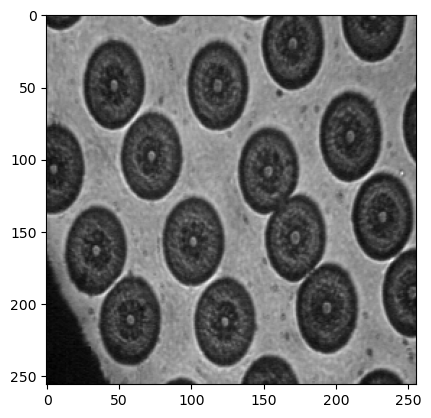

In [17]:
import cv2
import matplotlib.pyplot as plt

image = cv2.imread("images/SIC.png", cv2.IMREAD_GRAYSCALE)

plt.imshow(image, cmap="gray")
plt.show()

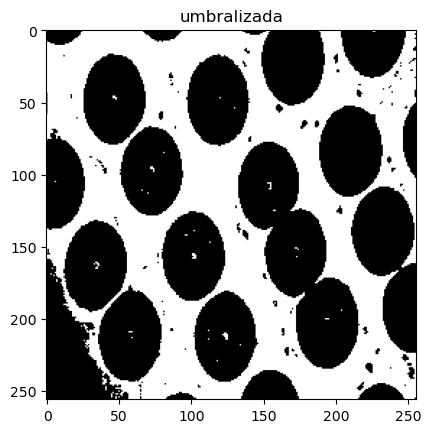

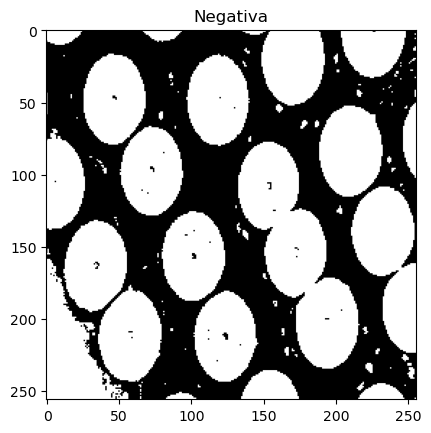

In [18]:
#Umbralice esta imagen de forma tal que las células del fondo sean separadas (umbral entre 55 y 70), y calcule su negativo.

#Umbralizar
retval, umbralizada = cv2.threshold(image, 67, 255, cv2.THRESH_BINARY)

plt.imshow(umbralizada, cmap="gray")
plt.title("umbralizada")
plt.show()

#Calcular negativo
negativo = cv2.bitwise_not(umbralizada)

plt.imshow(negativo, cmap="gray")
plt.title("Negativa")
plt.show()




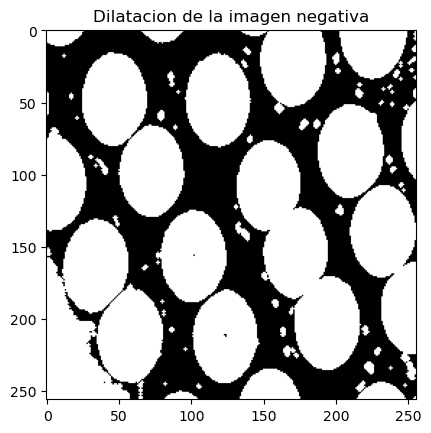

In [19]:
#Con una máscara en cruz de 3x3, haga dilataciones para rellenar los huecos al interior de las células. 
import numpy as np
from skimage.morphology import dilation, erosion, opening, closing

fp = np.array([
    [0,1,0],
    [1,1,1],
    [0,1,0]
])

dilated_image = dilation(negativo, footprint=fp)

plt.imshow(dilated_image, cmap="gray")
plt.title("Dilatacion de la imagen negativa")
plt.show()

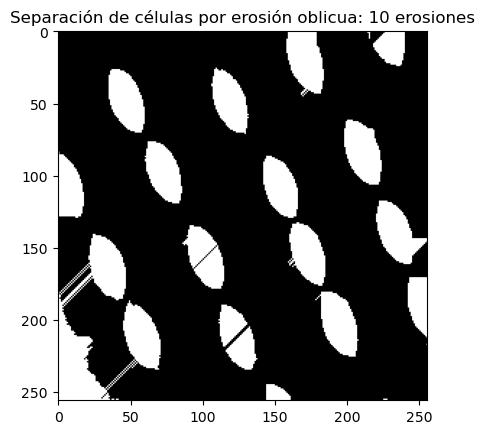

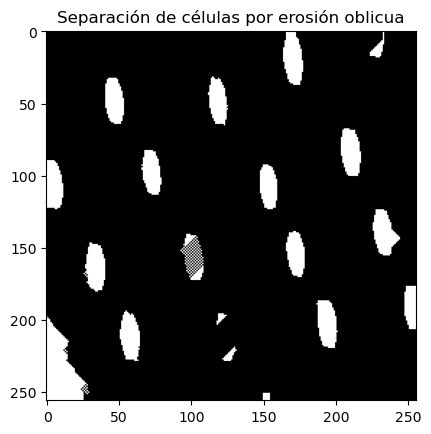

In [22]:
#Cambie de máscaras: se utilizarán ahora máscaras lineales (oblicuas). Utilice las mismas máscaras oblicuas creadas en el punto de apertura y cierre de este taller. Con el operador de erosión, separe las diferentes células

from skimage.morphology import dilation, erosion, opening, closing

fp_diagonal_1 = np.array([
    [0,0,1],
    [0,1,0],
    [1,0,0]
])

fp_diagonal_2 = np.array([
    [1,0,0],
    [0,1,0],
    [0,0,1]
])

fp_horizontal = np.array([
    [1,1,1]
])

fp_vertical = np.array([
    [1],
    [1],
    [1]
])

#Con el operador de erosión, separe las diferentes células

# 10 erosiones con la máscara /
eroded_image = erosion(dilated_image, footprint=fp_diagonal_1)
for i in range(9):
    eroded_image = erosion(eroded_image, footprint=fp_diagonal_1)
    
plt.imshow(eroded_image, cmap="gray")
plt.title("Separación de células por erosión oblicua: 10 erosiones")
plt.show()
    
# 6 erosiones con la máscara \
for i in range(6):
    eroded_image = erosion(eroded_image, footprint=fp_diagonal_2)

plt.imshow(eroded_image, cmap="gray")
plt.title("Separación de células por erosión oblicua")
plt.show()


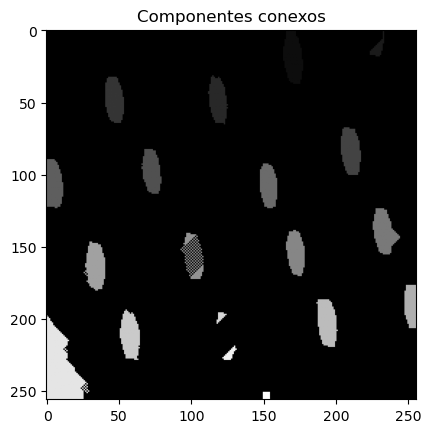

objeto:  1
objeto:  2
objeto:  3
objeto:  4
objeto:  5
objeto:  6
objeto:  7
objeto:  8
objeto:  9
objeto:  10
objeto:  11
objeto:  12
objeto:  13
objeto:  14
objeto:  15
objeto:  16
objeto:  17
objeto:  18
objeto:  19


In [ ]:
#Etiquete la imagen y visualice el resultado. Determine cuántas células enteras fueron detectadas 

from skimage.measure import label, regionprops

connected_components = label(eroded_image, background=0, connectivity=2)

plt.imshow(connected_components, cmap="gray")
plt.title("Componentes conexos")
plt.show()

regions = regionprops(connected_components)

for r in regions:
    print("objeto: ",r.label) # 19 objetos en total incluyendo el fondo
    
    